In [1]:
import os, sys, tempfile, subprocess
from coffea import processor
from coffea.nanoevents import NanoAODSchema, NanoEventsFactory
import matplotlib.pyplot as plt
import yaml

sidm_path = str(os.getcwd()).split('/sidm')[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities, scaleout, sidm_processor, llpnanoaodschema
from sidm.studies.cosmicVeto import functions

utilities.set_plot_style()
%matplotlib inline

In [2]:
TT = functions.get_bg_file_names("TTJets")
DY = functions.get_bg_file_names("DYJetsToLL")
QCD = functions.get_bg_file_names("QCD")
DB = functions.get_bg_file_names("Diboson")


In [3]:
channel_name = 'cr_1egmOr1mu_lj_withoutEta_phi'
output_signal_2mu = functions.load_output("signal_2mu2e", channel_name)
output_signal_4mu = functions.load_output("signal_4mu", channel_name)



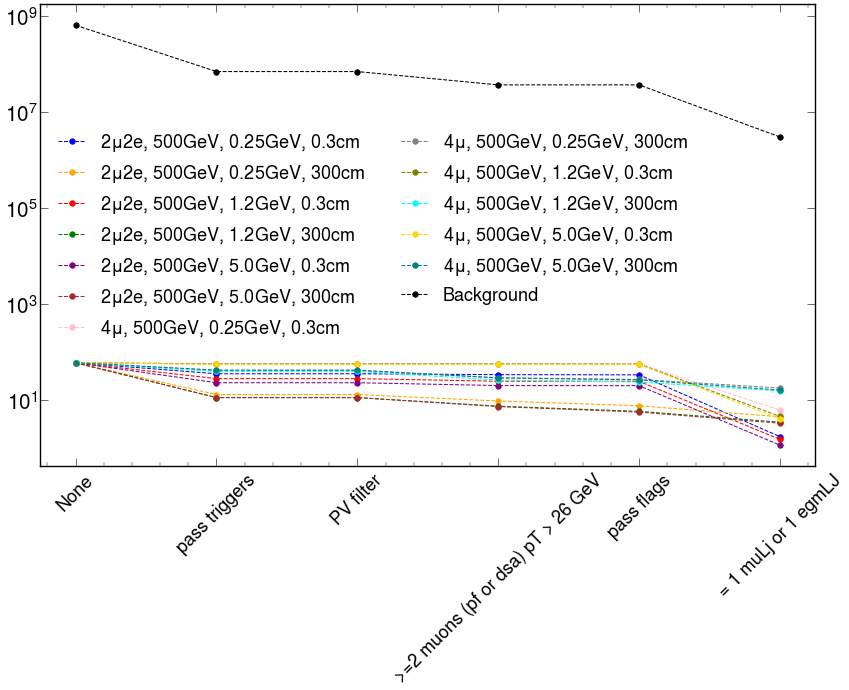

In [11]:
S = [
'2Mu2E_500GeV_0p25GeV_0p004mm',
'2Mu2E_500GeV_0p25GeV_4p0mm',
'2Mu2E_500GeV_1p2GeV_0p019mm',
'2Mu2E_500GeV_1p2GeV_19p0mm',
'2Mu2E_500GeV_5p0GeV_0p08mm',
'2Mu2E_500GeV_5p0GeV_80p0mm',

'4Mu_500GeV_0p25GeV_0p004mm',
'4Mu_500GeV_0p25GeV_4p0mm',
'4Mu_500GeV_1p2GeV_0p019mm',
'4Mu_500GeV_1p2GeV_19p0mm',
'4Mu_500GeV_5p0GeV_0p08mm',
'4Mu_500GeV_5p0GeV_80p0mm',
]
colors = ["blue", "orange", "red", "green", "purple", "brown", "pink", "gray", "olive", "cyan", "gold", "teal"]

plt.figure(figsize=(20, 12))
for j, s in enumerate(S):
    label = functions.get_signal_label(s)
    if label[0]=="2":
        cutflow= output_signal_2mu["out"][s]["cutflow"][channel_name]
    elif label[0] == "4":
        cutflow= output_signal_4mu["out"][s]["cutflow"][channel_name]
    else:
        print(f"cutflow not found for {s}")
    cut, N = functions.get_cutflow_list(cutflow)
    color = colors[j]
    plt.plot(cut,N, marker='o', linestyle = "--", markersize =8, color =color, label =label)
cutflow_bg = functions.sum_bg_cutflow(TT + DY + DB + QCD, channel_name,raw=False)
cut, N = functions.get_cutflow_list(cutflow_bg)
plt.plot(cut, N, label="Background", marker="o", linestyle = "--", markersize =8, color= "black" )
plt.legend( ncols=2, fontsize=26, title_fontsize=30)
plt.yscale("log")
plt.xticks(rotation=45, fontsize=26)
plt.yticks( fontsize=30)
plt.savefig(f"Plots/{channel_name}_cutflow_signal_bg.png", dpi=150)
plt.show()
plt.close()

